# IMPORT

Saving AmesHousing.csv to AmesHousing.csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 1

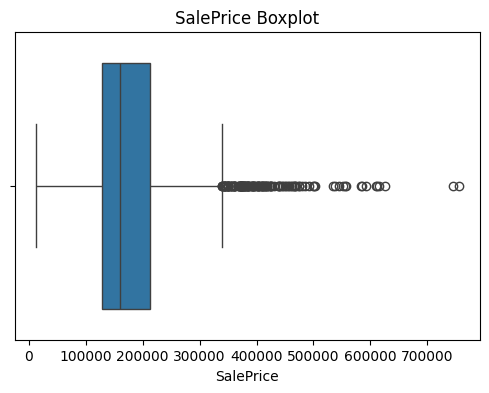

Saving AmesHousing.csv to AmesHousing (1).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

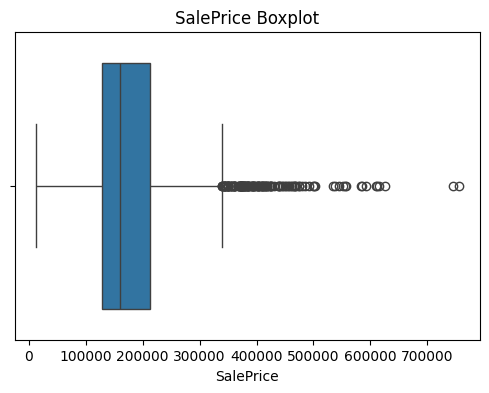

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from cleaning_01 import clean_data

Saving AmesHousing.csv to AmesHousing (2).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,1,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,1,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,1,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,1,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,1,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


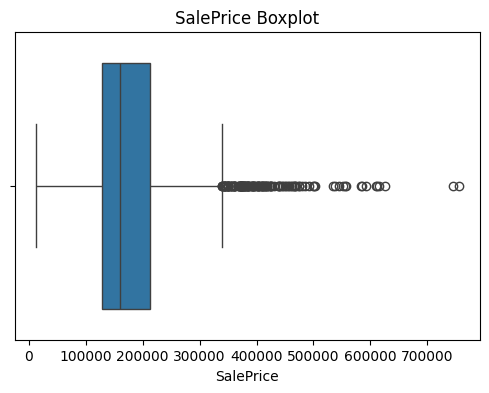

In [3]:
data = pd.read_csv("AmesHousing.csv")

result = clean_data(data)
df = result[0] if isinstance(result, tuple) else result

df.head()

-------------------------------

# Compute the mean and standard deviation


I calculated the mean and standard deviation for **SalePrice** manually using NumPy instead of relying on built-in pandas shortcuts. I chose SalePrice because it is the target variable, so understanding its average and spread is important before any deeper analysis. This step shows the central value of house prices and how much they vary across the dataset.

In [4]:
def calculate_target_stats(df):
    target = df["SalePrice"].to_numpy()

    mean_value = np.sum(target) / target.size
    std_value = np.sqrt(np.sum((target - mean_value) ** 2) / target.size)

    print("Mean:", mean_value)
    print("Standard Deviation:", std_value)

    return mean_value, std_value

In [5]:
calculate_target_stats(df)

Mean: 179956.70481228668
Standard Deviation: 76061.61121141634


(np.float64(179956.70481228668), np.float64(76061.61121141634))

----------------------

# Standardise one column by hand using broadcasting


I used Gr Liv Area because it is a strong numeric feature and represents the living area of the house. The column was standardized manually using the formula z = (x - mean) / std, then compared with StandardScaler to confirm both methods give the same result. This was done to show the mathematical idea behind scaling, not just the library output.

In [6]:
def compare_standardization(df):
    x = df["Gr Liv Area"].to_numpy()

    manual_mean = np.mean(x)
    manual_std = np.std(x)
    manual_z = (x - manual_mean) / manual_std

    scaler = StandardScaler()
    scaled_z = scaler.fit_transform(df[["Gr Liv Area"]]).flatten()

    print("Manual mean:", np.mean(manual_z))
    print("Manual std:", np.std(manual_z))
    print("Scaler mean:", np.mean(scaled_z))
    print("Scaler std:", np.std(scaled_z))

    return manual_z, scaled_z

In [7]:
manual_z, scaled_z = compare_standardization(df)

Manual mean: 3.637590797406656e-17
Manual std: 1.0
Scaler mean: 3.637590797406656e-17
Scaler std: 1.0


----------------------------------------

# Compute cosine similarity


Cosine similarity was computed using all numeric columns except SalePrice, then applied to the highest-price house and the lowest-price house. I excluded SalePrice because the goal was to compare the feature patterns of the two houses, not the target itself. This step measures how similar the two records are in direction, even if their actual values are very different.

In [8]:
def calculate_cosine_similarity(df):
    numeric_data = df.select_dtypes(include=np.number).drop(columns=["SalePrice"])

    highest_row = numeric_data.loc[df["SalePrice"].idxmax()]
    lowest_row = numeric_data.loc[df["SalePrice"].idxmin()]

    numerator = np.dot(highest_row, lowest_row)
    denominator = np.linalg.norm(highest_row) * np.linalg.norm(lowest_row)

    cosine_value = numerator / denominator

    print("Cosine similarity:", cosine_value)

    return cosine_value

In [9]:
calculate_cosine_similarity(df)

Cosine similarity: 0.9999999958449018


np.float64(0.9999999958449018)

-------------------------------------------

# Estimate a probability


I estimated a probability using Overall Qual and SalePrice to answer a practical question from the data. First, I treated houses with Overall Qual >= 8 as high-quality houses, then checked how many of them had a price above the 80th percentile. This gives a simple probability that connects house quality with high market value.

In [10]:
def estimate_high_quality_probability(df):
    price_limit = df["SalePrice"].quantile(0.80)
    high_quality_houses = df[df["Overall Qual"] >= 8]

    probability = (high_quality_houses["SalePrice"] > price_limit).mean()

    print("Probability:", probability)

    return probability

In [11]:
estimate_high_quality_probability(df)

Probability: 0.8094262295081968


np.float64(0.8094262295081968)

In [17]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)

print("folders created")
!find data -maxdepth 2 -type d

folders created
data
data/cleaned
data/raw
